In [52]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import xgboost as xgb
import random
import argparse
from pathlib import Path

In [57]:
def split_blocks_into_train_test(data_path, train_ratio=0.8, seed=1, output_file=None):
    """
    Смотрит какие блоки есть в директории и делит их на train и test списки
    
    Args:
        data_path: путь к директории с блоками
        train_ratio: доля блоков для тренировочной выборки (по умолчанию 0.8)
        seed: seed для воспроизводимости случайного разделения
        output_file: если указан, сохраняет списки в файл
    """
    
    # Устанавливаем seed для воспроизводимости
    random.seed(seed)
    
    # Получаем путь к директории
    data_dir = Path(data_path)
    
    # Проверяем существование директории
    if not data_dir.exists() or not data_dir.is_dir():
        print(f"Ошибка: Директория {data_path} не существует или не является директорией")
        return None, None
    
    # Получаем список всех поддиректорий (блоков)
    all_blocks = [d.name for d in data_dir.iterdir() if d.is_dir()]
    
    if not all_blocks:
        print(f"В директории {data_path} не найдено поддиректорий (блоков)")
        return [], []
    
    # Сортируем для стабильности
    all_blocks.sort()
    
    print(f"Найдено блоков: {len(all_blocks)}")
    print(f"Блоки: {all_blocks}")
    
    # Перемешиваем блоки
    shuffled_blocks = all_blocks.copy()
    random.shuffle(shuffled_blocks)
    
    # Вычисляем размер тренировочной выборки
    train_size = int(len(shuffled_blocks) * train_ratio)
    
    # Разделяем на train и test
    train_blocks = shuffled_blocks[:train_size]
    test_blocks = shuffled_blocks[train_size:]
    
    # Сортируем для удобства чтения
    train_blocks.sort()
    test_blocks.sort()
    
    print(f"\nРазделение (train_ratio={train_ratio}, seed={seed}):")
    print(f"Train блоков ({len(train_blocks)}): {train_blocks}")
    print(f"Test блоков ({len(test_blocks)}): {test_blocks}")
    
    # Если указан output_file, сохраняем списки
    if output_file:
        save_blocks_to_file(train_blocks, test_blocks, output_file, data_path, train_ratio, seed)
    
    return train_blocks, test_blocks

def load_features(path):
    df = pd.read_csv(path, low_memory=False)

    # --- 1. Удаляем строковые колонки ---
    df = df.drop(columns=["driving_inst", "driving_cell"], errors="ignore")

    # --- 2. Исправляем driving_cell_strength ---
    df["driving_cell_strength"] = pd.to_numeric(
        df["driving_cell_strength"],
        errors="coerce"   # "port" -> NaN
    )

    df["driving_cell_strength"] = df["driving_cell_strength"].fillna(0.0)

    df['driving_cell_strength'] = df['driving_cell_strength'].replace('port', -1)

    # --- 3. Убедиться что все признаки числовые ---
    for col in df.columns:
        if col != "net":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.fillna(0.0)

    return df

In [64]:
DATASET_ROOT = "/home/nzheludkov/phd/ml-critical-path-prediction/dataset/load_prediction"

train_blocks , test_blocks  = split_blocks_into_train_test("/home/nzheludkov/phd/ml-critical-path-prediction/dataset/load_prediction")

Найдено блоков: 15
Блоки: ['FIR_filter', 'Md5Core', 'ac97_top', 'aes_core', 'des3', 'dynamic_node_top_wrap', 'i2c_master_top', 'mc_top', 'pcm_slv_top', 'sasc_top', 'sha256', 'simple_spi_top', 'spi_top', 'trigonometric', 'usb_phy']

Разделение (train_ratio=0.8, seed=1):
Train блоков (12): ['FIR_filter', 'Md5Core', 'aes_core', 'des3', 'dynamic_node_top_wrap', 'i2c_master_top', 'mc_top', 'pcm_slv_top', 'sha256', 'simple_spi_top', 'trigonometric', 'usb_phy']
Test блоков (3): ['ac97_top', 'sasc_top', 'spi_top']


In [59]:
def load_block(block_name):
    feat_path = os.path.join(DATASET_ROOT, block_name, "features", "nets_load_features.csv")
    label_path = os.path.join(DATASET_ROOT, block_name, "labels", "*.csv")
    
    feat_file = glob.glob(feat_path)[0]
    label_file = glob.glob(label_path)[0]
    
    df_feat = load_features(feat_file)
    df_label = pd.read_csv(label_file)

    df = df_feat.merge(df_label, on="net")
    
    df = df_feat.merge(df_label, on="net")
    df["block"] = block_name
    
    return df

In [60]:
train_df = pd.concat([load_block(b) for b in train_blocks], ignore_index=True)
test_df  = pd.concat([load_block(b) for b in test_blocks], ignore_index=True)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (195905, 22)
Test size: (12201, 22)


In [61]:
TARGET = "wire_capacitance_spef"

feature_cols = [c for c in train_df.columns if c not in ["net", "block", TARGET]]

X_train = train_df[feature_cols].values
y_train = train_df[TARGET].values

X_test = test_df[feature_cols].values
y_test = test_df[TARGET].values

In [62]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [63]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("===== TEST METRICS =====")
print(f"RMSE: {rmse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R2  : {r2:.4f}")

===== TEST METRICS =====
RMSE: 0.000000
MAE : 0.000000
R2  : -0.0152


In [112]:
#MY XGB
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# get blocks
dataset_path = "/home/nzheludkov/phd/ml-critical-path-prediction/dataset/load_prediction"
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    
    # get nets_load_features.csv (feate store)
    df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')

    #get net labels
    df_y = pd.read_csv(f"{dataset_path}/{block}/labels/nets_load_labels.csv", sep=',')

    #fix driving_cell_strength column
    df["driving_cell_strength"] = df["driving_cell_strength"].fillna(0.0)
    df['driving_cell_strength'] = df['driving_cell_strength'].replace('port', -1)
    
    # drop all Nan rows
    df = df.dropna()

    # drop bad features term_bbox_xmin, term_bbox_ymin, term_bbox_xmax, term_bbox_ymax, term_bbox_dy, term_bbox_dx
    #driving_inst, driving_cell 
    df = df.drop(columns=['term_bbox_xmin', 'term_bbox_ymin', 'term_bbox_xmax', 
                         'term_bbox_ymax', 'term_bbox_dy', 'term_bbox_dx', 'driving_inst', 'driving_cell'])

    #merge feats and labels
    df = df.merge(df_y, on="net")

    # Add block identifier
    df['block_id'] = block
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

/tmp/ipykernel_5604/1750882121.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')
/tmp/ipykernel_5604/1750882121.py:21: DtypeWarning: Columns (0: driving_cell_strength) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{dataset_path}/{block}/features/nets_load_features.csv", sep=',')


Всего уникальных блоков: 15
Всего блоков: 15
Количество фолдов: 5
Блоков в обучении на фолд: 12
Блоков в тесте на фолд: 3

--- Фолд 1 ---
Тренировочные блоки (12): ['mc_top' 'ac97_top' 'dynamic_node_top_wrap' 'Md5Core' 'FIR_filter'
 'sha256' 'usb_phy' 'aes_core' 'i2c_master_top' 'des3' 'sasc_top'
 'spi_top']
Тестовые блоки (3): ['trigonometric' 'pcm_slv_top' 'simple_spi_top']
Тренировочные samples: 196789
Тестовые samples: 11317
MSE: 0.0000
MAE: 0.0000
MAPE: 4.7557
R²: -0.0409

--- Фолд 2 ---
Тренировочные блоки (12): ['trigonometric' 'pcm_slv_top' 'simple_spi_top' 'Md5Core' 'FIR_filter'
 'sha256' 'usb_phy' 'aes_core' 'i2c_master_top' 'des3' 'sasc_top'
 'spi_top']
Тестовые блоки (3): ['mc_top' 'ac97_top' 'dynamic_node_top_wrap']
Тренировочные samples: 176857
Тестовые samples: 31249
MSE: 0.0000
MAE: 0.0000
MAPE: 5.8517
R²: -0.0011

--- Фолд 3 ---
Тренировочные блоки (12): ['trigonometric' 'pcm_slv_top' 'simple_spi_top' 'mc_top' 'ac97_top'
 'dynamic_node_top_wrap' 'usb_phy' 'aes_core' 'i

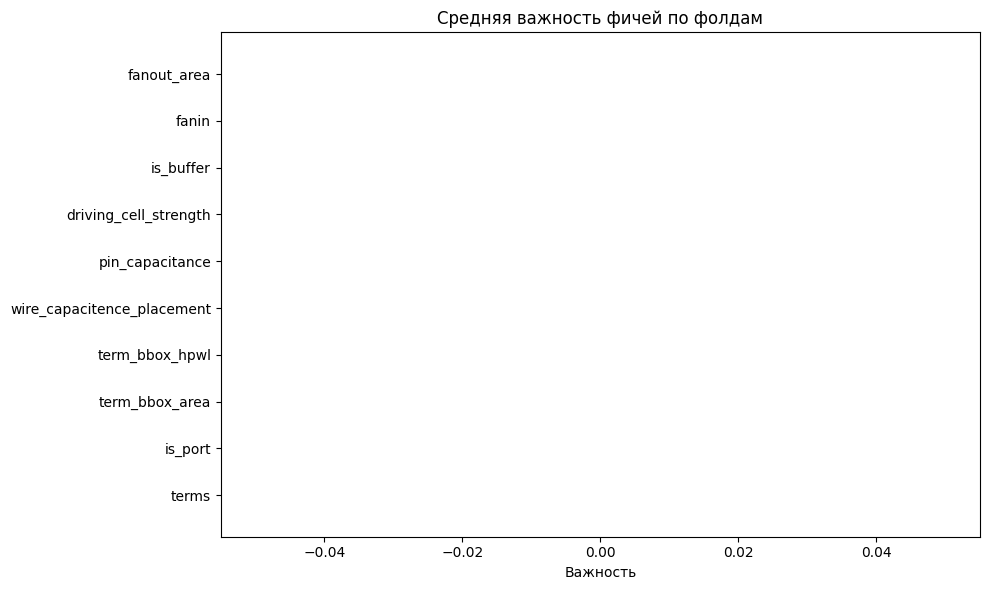


Обучение финальной модели на всех данных...
Финальная модель обучена!


In [113]:
# Определяем фичи и таргет
#features = [col for col in df.columns if col not in ['cap', 'block_id']]
features = ['terms', 'is_port', 'term_bbox_area', 'term_bbox_hpwl', 
            'wire_capacitence_placement', 'pin_capacitance', 'driving_cell_strength', 
            'is_buffer', 'fanin', 'fanout_area']
X = df[features]
y = df['wire_capacitance_spef']
groups = df['block_id']

# Проверяем количество уникальных блоков
unique_blocks = df['block_id'].unique()
print(f"Всего уникальных блоков: {len(unique_blocks)}")

# Создаем кастомную стратегию для 5 фолдов (30 train / 5 test)
n_splits = 5
n_blocks_total = len(unique_blocks)
n_test_blocks = 3
n_train_blocks = n_blocks_total - n_test_blocks

print(f"Всего блоков: {n_blocks_total}")
print(f"Количество фолдов: {n_splits}")
print(f"Блоков в обучении на фолд: {n_train_blocks}")
print(f"Блоков в тесте на фолд: {n_test_blocks}")

# Случайно перемешиваем блоки для разнообразия фолдов
np.random.seed(42)
shuffled_blocks = np.random.permutation(unique_blocks)

# Метрики для хранения результатов
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []
feature_importances = []

# Кастомная кросс-валидация по блокам
for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Вычисляем индексы для тестовых блоков (скользящее окно)
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    
    # Если вышли за границы, начинаем сначала
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    print(f"Тренировочные блоки ({len(train_blocks)}): {train_blocks}")
    print(f"Тестовые блоки ({len(test_blocks)}): {test_blocks}")
    
    # Создаем маски для train/test
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем XGBoost
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Вычисляем метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    r2_scores.append(r2)
    
    # Сохраняем важность фичей
    feature_importances.append(model.feature_importances_)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²: {r2:.4f}")

# Выводим итоговые результаты
print("\n" + "="*50)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ")
print("="*50)
print(f"Среднее MSE: {np.mean(mse_scores):.4f} (±{np.std(mse_scores):.4f})")
print(f"Среднее MAE: {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Среднее MAPE: {np.mean(mape_scores):.4f} (±{np.std(mape_scores):.4f})")
print(f"Среднее R²: {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# Анализ важности фичей
avg_feature_importance = np.mean(feature_importances, axis=0)
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': avg_feature_importance
}).sort_values('importance', ascending=False)

print("\nВажность фичей (средняя по фолдам):")
print(feature_importance_df)

# Визуализация важности фичей (опционально)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Средняя важность фичей по фолдам')
plt.tight_layout()
plt.show()

# Обучение финальной модели на всех данных (опционально)
print("\nОбучение финальной модели на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
final_model.fit(X_scaled, y)

print("Финальная модель обучена!")

In [94]:
df.corr(method='pearson', min_periods=1, numeric_only=True)

,terms,is_port,term_bbox_area,term_bbox_hpwl,term_bbox_ar,wire_capacitence_placement,pin_capacitance,is_inverter,is_buffer,fanin,driving_cell_area,fanout_area,wire_capacitance_spef
terms,1.000000,0.049825,0.119391,0.269615,-0.001649,0.379135,0.882702,-0.004691,0.136196,-0.118152,0.011447,0.571966,0.399881
is_port,0.049825,1.000000,0.141628,0.186520,-0.000691,0.180928,-0.011257,-0.014742,-0.110610,-0.255726,-0.175877,-0.106828,0.173024
term_bbox_area,0.119391,0.141628,1.000000,0.671500,-0.000452,0.658620,0.105233,-0.007683,0.044254,-0.077941,0.017371,0.057154,0.631542
term_bbox_hpwl,0.269615,0.186520,0.671500,1.000000,-0.001694,0.989165,0.249930,-0.025877,0.144370,-0.165735,0.037698,0.195422,0.964870
term_bbox_ar,-0.001649,-0.000691,-0.000452,-0.001694,1.000000,-0.001713,-0.001833,-0.000544,-0.004071,0.001864,0.003600,-0.002955,-0.001744
wire_capacitence_placement,0.379135,0.180928,0.658620,0.989165,-0.001713,1.000000,0.346717,-0.025730,0.154396,-0.171031,0.038014,0.263398,0.982150
pin_capacitance,0.882702,-0.011257,0.105233,0.249930,-0.001833,0.346717,1.000000,-0.000387,0.190916,-0.143816,-0.025330,0.609695,0.371243
is_inverter,-0.004691,-0.014742,-0.007683,-0.025877,-0.000544,-0.025730,-0.000387,1.000000,-0.087061,-0.091160,-0.082799,0.000257,-0.026342
is_buffer,0.136196,-0.110610,0.044254,0.144370,-0.004071,0.154396,0.190916,-0.087061,1.000000,-0.683994,-0.496611,0.100964,0.160551
fanin,-0.118152,-0.255726,-0.077941,-0.165735,0.001864,-0.171031,-0.143816,-0.091160,-0.683994,1.000000,0.408767,-0.062011,-0.173045


In [95]:
# Полный рабочий пример
def feature_selection_pipeline(df, target_col, corr_threshold=0.1):
    # Вычисляем корреляции
    correlations = df.corr()[target_col].drop(target_col)
    
    # Отбираем фичи по порогу
    selected_features = correlations[abs(correlations) > corr_threshold].index.tolist()
    
    print(f"Всего фич: {len(df.columns) - 1}")
    print(f"Отобрано фич: {len(selected_features)}")
    print(f"Лучшие фичи:")
    for feature in selected_features:
        print(f"  {feature}: {correlations[feature]:.3f}")

    print(selected_features)
    return selected_features

def select_features_with_multicollinearity(df, target_col, corr_threshold=0.3, multicoll_threshold=0.9):
    """
    Отбор фич с учетом мультиколлинеарности
    """
    corr_matrix = df.corr()
    target_corrs = corr_matrix[target_col].drop(target_col)
    
    # Отбираем фичи с достаточной корреляцией с целевой
    candidate_features = target_corrs[abs(target_corrs) > corr_threshold].index.tolist()
    
    # Проверяем мультиколлинеарность между фичами
    selected_features = []
    for feature in candidate_features:
        # Проверяем корреляцию с уже отобранными фичами
        high_corr_with_selected = False
        for selected in selected_features:
            if abs(corr_matrix.loc[feature, selected]) > multicoll_threshold:
                high_corr_with_selected = True
                break
        
        if not high_corr_with_selected:
            selected_features.append(feature)

    print("Лучшие фичи с учетом мульколинеарности")
    print(selected_features)
    
    #return selected_features

In [111]:
##DATA ANALYSIS

#df = df.drop(columns=['block_id'])

#capacitence
df.corr()['wire_capacitance_spef']

#feature selection
feature_selection_pipeline(df, 'wire_capacitance_spef')

#feature selection include multicolinear
#select_features_with_multicollinearity(df, 'wire_capacitance_spef')

Всего фич: 13
Отобрано фич: 10
Лучшие фичи:
  terms: 0.400
  is_port: 0.173
  term_bbox_area: 0.632
  term_bbox_hpwl: 0.965
  wire_capacitence_placement: 0.982
  pin_capacitance: 0.371
  driving_cell_strength: 0.502
  is_buffer: 0.161
  fanin: -0.173
  fanout_area: 0.276
['terms', 'is_port', 'term_bbox_area', 'term_bbox_hpwl', 'wire_capacitence_placement', 'pin_capacitance', 'driving_cell_strength', 'is_buffer', 'fanin', 'fanout_area']


['terms',
 'is_port',
 'term_bbox_area',
 'term_bbox_hpwl',
 'wire_capacitence_placement',
 'pin_capacitance',
 'driving_cell_strength',
 'is_buffer',
 'fanin',
 'fanout_area']

In [108]:
df

,terms,is_port,term_bbox_area,term_bbox_hpwl,term_bbox_ar,wire_capacitence_placement,pin_capacitance,is_inverter,driving_cell_strength,is_buffer,fanin,driving_cell_area,fanout_area,wire_capacitance_spef
0,2,0,16.8800,8.67,1.940,7.430000e-16,1.790000e-15,0,1,0,2,3.75,28.780,7.558000e-16
1,2,0,8.1880,5.72,0.995,4.900000e-16,1.750000e-15,0,0,0,3,5.00,30.030,4.778000e-16
2,2,0,1.5850,3.24,0.229,2.770000e-16,1.750000e-15,0,1,0,4,6.26,30.030,5.245000e-16
3,2,0,14.7300,8.19,0.482,7.020000e-16,1.750000e-15,0,0,0,3,5.00,30.030,7.107000e-16
4,2,0,0.2688,3.21,36.300,2.750000e-16,1.750000e-15,0,0,0,3,5.00,30.030,3.063000e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208101,3,0,399.4000,66.60,0.111,5.700000e-15,6.520000e-15,0,2,1,1,5.00,12.510,5.913000e-15
208102,2,0,22.4000,9.55,0.767,8.180000e-16,2.250000e-15,0,1,1,1,3.75,3.754,7.514000e-16
208103,3,0,27.9700,12.20,3.030,1.050000e-15,4.440000e-15,0,1,1,1,3.75,7.508,1.074000e-15
208104,17,0,20620.0000,299.00,0.569,3.910000e-14,3.700000e-14,0,8,1,1,15.00,123.900,3.963000e-14


In [67]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# get blocks
dataset_path = "/home/nzheludkov/phd/ml-critical-path-prediction/dataset/load_prediction"
items = os.listdir(dataset_path)
blocks = [item for item in items if os.path.isdir(os.path.join(dataset_path, item))]

df_blocks_list = []
block_names = []

for block in blocks:
    # get net_feat.csv (feate store and labels)
    df = pd.read_csv(f"./{dataset_path}/{block}/features/nets_load_features.csv", sep=',')

    # drop all nets with zero capacitence
    df = df[df['cap'] != 0]
    df = df[df['pin_cap'] != 0]

    # drop all Nan rows
    df = df.dropna()

    # drop net name column
    df = df.drop(columns=['net'], axis=1)
    
    # Add block identifier
    df['block_id'] = block
    
    # append df to common df
    df_blocks_list.append(df)
    block_names.append(block)

# create common df
df = pd.concat(df_blocks_list, ignore_index=True)

# transfer capacintece from pF to fF
df['cap'] = df['cap'] * 1000
df['pin_cap'] = df['pin_cap'] * 1000
df['wireload_fan_cap'] = df['wireload_fan_cap'] * 1000
df['wireload_hpwl_cap'] = df['wireload_hpwl_cap'] * 1000

# add block area feature
df['block_area'] = df['block_width'] * df['block_height']

# add area feature
df['gcell_area'] = (df['urx'] - df['llx']) * (df['ury'] - df['lly'])

# add aspect ration feat
df['gcell_ar'] = (df['urx'] - df['llx']) / (df['ury'] - df['lly'])

df['abs_x'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']
df['abs_y'] = (((df['ury'] - df['lly']) / 2) + df['lly']) / df['block_height']

df['dist_to_right'] = ((df['block_width'] - ((df['urx'] - df['llx']) / 2) + df['llx'])) / df['block_width']
df['dist_to_left'] = (((df['urx'] - df['llx']) / 2) + df['llx']) / df['block_width']

df['dist_to_top'] = (df['block_height'] - (((df['ury'] - df['lly']) / 2) + df['lly'])) / df['block_height']
df['dist_to_bottom'] = ((((df['ury'] - df['lly']) / 2) + df['lly']))

# ration wire cap / pin cap
# df ['wire_to_pin_cap_ratio'] = df['cap'] / df['pin_cap'] 

# drop metal segs
df = df.drop(columns=['m2_segs', 'm3_segs', 'm4_segs', 'm5_segs', 'm6_segs', 'm7_segs'])

# drop all labels except cap
df = df.drop(columns=['length', 'vias', 'segs'])

# Определяем фичи и таргет
#features = [col for col in df.columns if col not in ['cap', 'block_id']]
features = ['fanin', 'fanout', 'fanin_area', 'fanout_area', 'hpwl', 'hpwl_min', 'hpwl_max', 'hpwl_mean', 'hpwl_stddev', 'cell_density', 'pin_cap', 'wireload_fan_cap', 'wireload_hpwl_cap', 'gcell_area', 'gcell_ar']
X = df[features]
y = df['cap']
groups = df['block_id']

# Проверяем количество уникальных блоков
unique_blocks = df['block_id'].unique()
print(f"Всего уникальных блоков: {len(unique_blocks)}")

# Создаем кастомную стратегию для 7 фолдов (30 train / 5 test)
n_splits = 7
n_blocks_total = len(unique_blocks)
n_test_blocks = 5
n_train_blocks = n_blocks_total - n_test_blocks

print(f"Всего блоков: {n_blocks_total}")
print(f"Количество фолдов: {n_splits}")
print(f"Блоков в обучении на фолд: {n_train_blocks}")
print(f"Блоков в тесте на фолд: {n_test_blocks}")

# Случайно перемешиваем блоки для разнообразия фолдов
np.random.seed(42)
shuffled_blocks = np.random.permutation(unique_blocks)

# Метрики для хранения результатов
mse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []
feature_importances = []

# Кастомная кросс-валидация по блокам
for fold in range(n_splits):
    print(f"\n--- Фолд {fold + 1} ---")
    
    # Вычисляем индексы для тестовых блоков (скользящее окно)
    start_idx = fold * n_test_blocks
    end_idx = start_idx + n_test_blocks
    
    # Если вышли за границы, начинаем сначала
    if end_idx > n_blocks_total:
        start_idx = 0
        end_idx = n_test_blocks
    
    test_blocks = shuffled_blocks[start_idx:end_idx]
    train_blocks = np.array([block for block in shuffled_blocks if block not in test_blocks])
    
    print(f"Тренировочные блоки ({len(train_blocks)}): {train_blocks}")
    print(f"Тестовые блоки ({len(test_blocks)}): {test_blocks}")
    
    # Создаем маски для train/test
    train_mask = df['block_id'].isin(train_blocks)
    test_mask = df['block_id'].isin(test_blocks)
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print(f"Тренировочные samples: {len(X_train)}")
    print(f"Тестовые samples: {len(X_test)}")
    
    # Масштабирование фичей
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Обучаем XGBoost
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train)
    
    # Предсказания
    y_pred = model.predict(X_test_scaled)
    
    # Вычисляем метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    mse_scores.append(mse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    r2_scores.append(r2)
    
    # Сохраняем важность фичей
    feature_importances.append(model.feature_importances_)
    
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"R²: {r2:.4f}")

# Выводим итоговые результаты
print("\n" + "="*50)
print("ИТОГИ КРОСС-ВАЛИДАЦИИ")
print("="*50)
print(f"Среднее MSE: {np.mean(mse_scores):.4f} (±{np.std(mse_scores):.4f})")
print(f"Среднее MAE: {np.mean(mae_scores):.4f} (±{np.std(mae_scores):.4f})")
print(f"Среднее MAPE: {np.mean(mape_scores):.4f} (±{np.std(mape_scores):.4f})")
print(f"Среднее R²: {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.4f})")

# Анализ важности фичей
avg_feature_importance = np.mean(feature_importances, axis=0)
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': avg_feature_importance
}).sort_values('importance', ascending=False)

print("\nВажность фичей (средняя по фолдам):")
print(feature_importance_df)

# Визуализация важности фичей (опционально)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность')
plt.title('Средняя важность фичей по фолдам')
plt.tight_layout()
plt.show()

# Обучение финальной модели на всех данных (опционально)
print("\nОбучение финальной модели на всех данных...")
final_scaler = StandardScaler()
X_scaled = final_scaler.fit_transform(X)

final_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
final_model.fit(X_scaled, y)

print("Финальная модель обучена!")

NameError: name 'breack' is not defined